# <font style="font-family:roboto;color:#455e6c"> Validation of interatomic potentials </font>  

<div class="admonition note" name="html-admonition" style="background:#e3f2fd; padding: 10px">
<font style="font-family:roboto;color:#455e6c"> <b> DPG Tutorial: Automated Workflows and Machine Learning for Materials Science Simulations </b> </font> </br>
<font style="font-family:roboto;color:#455e6c"> 16 March 2025 </font> </br> </br>
Marvin Poul, Sarath Menon, Haitham Gaafer, Jörg Neugebauer </br>
<i> Max Planck Institute for Sustainable Materials </i></br>
</br>
Minaam Qamar, Ralf Drautz </br>
<i> Ruhr-Universität Bochum </i></br>
</br>
Tilmann Hickel </br>
<i> Bundesanstalt für Materialforschung und -prüfung </i></br>
</div>

To ensure that our fitted ACE potentials provide reliable predictions, it is crucial to validate them against reference data from DFT calculations or experiments. In this notebook, we will use previously fitted ACE potential(s) to compute key properties—namely, energies, equilibrium volumes, and bulk moduli—for various phases. 

This validation step corresponds to Level 2 validation from the schematic, and is essential to confirm that the potentials capture the underlying physics accurately and can be confidently used for further simulations and analysis.


<img src="img/validation_schematic.png" alt="Validation schematic" width="700"/>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dataclasses import dataclass
from ase.atoms import Atoms
from pyiron_core import as_function_node, as_inp_dataclass_node, Workflow, Node

/cmmc/ptmp/pyironhb/mambaforge/envs/pyiron_mpie_cmti_2026-01-26/lib/python3.12/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
@as_inp_dataclass_node
@dataclass
class GenericOptimizerSettings:
    max_steps: int = 10
    force_tolerance: float = 1e-2

In [3]:
@as_function_node
def CalculateEVCurve(
    structure: Atoms,
    calculator: Node,
    num_of_points: int = 7,
    vol_range: float = 0.3,
    per_atom: bool = True,
    opt: dict | None = None,
):
    """
    Computes an energy vs volume (EV) curve for a given structure.

    Args:
        structure (Atoms): atomic structure
        calculator (AseCalculatorConfig): energy/force engine to use
        num_of_points (int): volume samples
        vol_range (float): minimum/maximum volumetric strain
        per_atom (float): output per atom quantities rather than supercell quantities

    Returns:
        DataFrame: columns 'volume', 'energy', 'ase_atoms'
    """
    from ase.optimize import BFGS
    from ase.filters import ExpCellFilter

    volume_factors = np.linspace((1 - vol_range)**(1/3), (1.0 + vol_range)**(1/3), num_of_points)

    structure = structure.copy()

    if per_atom:
        nd = len(structure)
    else:
        nd = 1

    calculator.inputs.use_symmetry = False
    structure.calc = calculator.pull()
    initial_volume = structure.get_volume()

    data = {"volume": [], "energy": [], "ase_atoms":[]}

    for factor in volume_factors:
        scaled_structure = structure.copy()
        scaled_structure.set_cell(structure.cell * factor, scale_atoms=True)
        calculator.inputs.use_symmetry = False
        scaled_structure.calc = calculator.pull()

        if opt is not None:
            opt = BFGS(scaled_structure)
            # Relax atomic positions
            opt.run(fmax=opt.force_tolerance, steps=opt.max_steps)

        energy = scaled_structure.get_potential_energy()
        volume = scaled_structure.get_volume()

        data["volume"].append(volume/nd)
        data["energy"].append(energy/nd)
        data["ase_atoms"].append(scaled_structure)

    df = pd.DataFrame(data)
    return df

In [4]:
def birch_murnaghan(vol, E0, V0, B0, BP):
    """
    Birch-Murnaghan EOS.
    """
    E = E0 + (9.0*V0*B0)/16.0 * ( ((V0/vol)**(2.0/3.0)-1.0)**3.0 *BP +
        ((V0/vol)**(2.0/3.0)-1.0)**2.0 * (6.0-4.0*(V0/vol)**(2.0/3.0)))
    return E

In [5]:
@as_function_node
def FitBirchMurnaghanEOS(ev_curve_df: pd.DataFrame) -> tuple[float, float, float]:
    """
    Fits the energy vs volume data to the Birch-Murnaghan EOS
    and returns a tuple of equilibrium properties: (E0, V0, B0).
    """
    from scipy.optimize import curve_fit

    volumes = ev_curve_df["volume"].values
    energies = ev_curve_df["energy"].values

    # Initial guesses for the fitting parameters
    V0_guess = volumes[np.argmin(energies)]
    E0_guess = min(energies)
    B0_guess = 1.0  # in eV/Å³
    B1_guess = 4.0

    popt, _ = curve_fit(birch_murnaghan, volumes, energies, p0=[E0_guess, V0_guess, B0_guess, B1_guess])
    E0, V0, B0, B1 = popt
    B0_GPa = B0 * 160.21766208  # Conversion factor

    return E0, V0, B0_GPa

In [6]:
def generate_CaMg_ortho():
    from ase import Atoms
    # Lattice vectors
    cell = np.array([
        [3.692641, 0.0, 0.0000000000000002],
        [-0.0000000000000004, 5.809565, 0.0000000000000004],
        [0.0, 0.0, 5.9892969999999996]
    ])

    # Element symbols
    symbols = ['Ca', 'Ca', 'Mg', 'Mg']

    # Fractional coordinates
    scaled_positions = np.array([
        [0.0000000000000000, 0.0000000000000000, 0.0932210000000000],
        [0.5000000000000000, 0.5000000000000000, 0.9067790000000000],
        [0.5000000000000000, 0.0000000000000000, 0.5849690000000000],
        [0.0000000000000000, 0.5000000000000000, 0.4150310000000000]
    ])

    # Create ASE Atoms object
    atoms = Atoms(symbols=symbols, scaled_positions=scaled_positions, cell=cell, pbc=True)

    return atoms

In [7]:
@as_function_node()
def PlotEVCurve(
    ev_curve_df: pd.DataFrame,
    xlabel: str = "Volume (Å³)",
    ylabel: str = "Energy (eV)",
    title: str = "Energy vs Volume Curve",
    fontsize: int = 12
):
    """
    Plots the Energy vs. Volume (EV) curve from a computed EV dataset.

    Args:
        ev_curve_df (pd.DataFrame): DataFrame containing 'volume' and 'energy' columns.
        xlabel (str, optional): Label for the x-axis. Defaults to "Volume (Å³)".
        ylabel (str, optional): Label for the y-axis. Defaults to "Energy (eV)".
        title (str, optional): Title of the plot. Defaults to "Energy vs Volume Curve".
        fontsize (int, optional): Font size for labels and title. Defaults to 12.

    Returns:
        fig, ax: The matplotlib figure and axis objects.
    """
    fig, ax = plt.subplots()
    ax.plot(ev_curve_df['volume'], ev_curve_df['energy'], marker='o', linestyle='-', color='b')
    ax.set_xlabel(xlabel, fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_title(title, fontsize=fontsize)
    # ax.legend()
    return ax

In [8]:
@as_function_node
def Grace(model: str = "GRACE-FS-OAM",  use_symmetry=True):
    """Universal Graph Atomic Cluster Expansion models."""
    import os
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
    from tensorpotential.calculator import grace_fm
    grace_obj = grace_fm(model)
    return grace_obj

In [9]:
fmax = 0.01,
max_steps = 500,
num_of_points = 7,
vol_range = 0.1,
per_atom = True,
optimize = False,
xlabel = "Volume (Å³)",
ylabel = "Energy (eV)",
title = "Energy vs Volume Curve",
fontsize = 12

### <font style="font-family:roboto;color:#455e6c"> ACE and GRACE Calculators </font>  

For simulations involving ACE and GRACE potentials, having ASE-compatible calculators is essential. In our workflow, these calculators are implemented as Pyiron nodes.

In [10]:
@as_function_node
def Ace(potential_file, use_symmetry=True):
    from pyace import PyACECalculator
    calc = PyACECalculator(potential_file)
    from logging import ERROR
    from pyiron_snippets.logger import logger
    logger.setLevel(ERROR)
    return calc

In [11]:
# provide the file path to the ACE potential
potential_path = "potentials/Better_potential.yace"
potential_path = "potentials/Ca_Mg_linear_potential.yace"


ace = Ace(potential_path)

Several pre-fitted GRACE foundation models are available for use. You can choose from the following options:

- `MP_GRACE_1L_r6_4Nov2024`
- `MP_GRACE_1L_r6_07Nov2024`
- `MP_GRACE_2L_r6_11Nov2024`
- `MP_GRACE_2L_r5_4Nov2024`
- `MP_GRACE_2L_r5_07Nov2024`
- `GRACE_2L_OAM_28Jan25`
- `GRACE-1L-OAM_2Feb25`

For further details about the GRACE foundation models, please refer to the [Grace documentation](https://gracemaker.readthedocs.io/en/latest/gracemaker/foundation/).

Note that you only need to provide the model string as an argument—the associated potential files will be downloaded at runtime.


In [12]:
grace = Grace('GRACE-FS-OMAT')

In [13]:
# set one of ace or grace calcs as the default calculator for further calculations

# calc = grace_calc
calc = ace

### <font style="font-family:roboto;color:#455e6c"> Basic workflow for validation of energy-volume curves </font>  

In the current notebook, we will utilize the defined models and predict the energies, volumes, and bulk moduli of certain phases. We accomplish this through a series of workflow nodes that perform the following tasks:

1. **Build the Structure:**  
   Using a minimal input (such as an element string, e.g. `"Ca"`), we generate a bulk atomic structure using the `Bulk` node from `pyiron_nodes`. This node creates the structure based on common crystallographic data.

2. **Structure Optimization:**  
   The generated structure is optimized using the chosen calculator. In this step, the atomic positions and cell parameters are relaxed (using algorithms such as BFGS) until the forces are below a specified threshold. This optimization is critical to ensure that the following energy-volume calculations are accurate.

3. **Energy–Volume (EV) Curve Calculation:**  
   Once optimized, the workflow computes an EV curve by scaling the unit cell around the equilibrium volume. For each scaled structure, the potential energy is calculated.

4. **Plotting:**  
   Optionally, the EV curve and the fitted EOS are plotted. This allows us to visually assess the smoothness of the potential energy landscape predicted by the models.

5. **Fitting the Birch–Murnaghan Equation of State:**  
   The computed EV curve is fitted to the Birch–Murnaghan equation of state (EOS). This fitting yields important physical quantities:
   - **E0:** Equilibrium energy
   - **V0:** Equilibrium volume
   - **B0:** Bulk modulus  
   These parameters are essential for comparing the ACE potential predictions with DFT or experimental reference data.




#### <font style="font-family:roboto;color:#455e6c"> Build the structure </font>  

Use an in-built node `from pyiron_nodes.atomistic.structure.build import Bulk` to generate atomic structures. For single-element phases, the node automatically generates the ground-state structure for the given element with a rough guess for the lattice parameter.

Execute `Bulk?` for more details

In [14]:
from pyiron_core.pyiron_nodes.atomistic.structure.build import Bulk 
# Bulk?

In [15]:
bulk_struc = Bulk("Ca", cubic=True)
bulk_struc = bulk_struc.pull()
bulk_struc

Ca: [0. 0. 0.]
Ca: [0.   2.79 2.79]
Ca: [2.79 0.   2.79]
Ca: [2.79 2.79 0.  ]
tags: 
    indices: [0 0 0 0]
pbc: [ True  True  True]
cell: 
Cell([5.58, 5.58, 5.58])

#### <font style="font-family:roboto;color:#455e6c"> Structure optimization </font> 

The generated structure may not be in equilibirum. Before proceeding further, it is important that the structure is optimized.

We use a predefined `OptimizeStructure` function to relax both the atomic positions and cell vectors.

In [16]:
from enum import Enum

class RelaxMode(Enum):
    VOLUME = "volume"
    # CELL = "cell"
    INTERNAL = "internal"
    FULL = "full"

    def apply_filter_and_constraints(self, structure):
        match self:
            case RelaxMode.VOLUME:
                structure.set_constraint(FixAtoms(np.ones(len(structure),dtype=bool)))
                return FrechetCellFilter(structure, hydrostatic_strain=True)
            case RelaxMode.INTERNAL:
                return structure
            case RelaxMode.FULL:
                return FrechetCellFilter(structure)
            case _:
                raise ValueError("Lazy Marvin")

In [17]:
from pyiron_core.pyiron_workflow import Node
from ase.filters import StrainFilter, FrechetCellFilter

In [18]:
@as_function_node
def Relax(mode: str | RelaxMode, calculator: Node, opt: Node, structure: Atoms) -> Atoms:
    from ase.optimize import LBFGS
    from ase.calculators.singlepoint import SinglePointCalculator

    if isinstance(mode, str):
        mode = mode.lower()
    mode = RelaxMode(mode)

    structure = structure.copy()

    # FIXME: meh
    match mode:
        case RelaxMode.VOLUME:
            calculator.inputs.use_symmetry = True
            structure.calc = calculator.pull()
        case RelaxMode.FULL | RelaxLoop.INTERNAL:
            calculator.inputs.use_symmetry = False
            structure.calc = calculator.pull()
        case _:
            assert False

    filtered_structure = mode.apply_filter_and_constraints(structure)
    lbfgs = LBFGS(filtered_structure, logfile="/dev/null")
    lbfgs.run(fmax=opt.inputs.force_tolerance.value, steps=opt.inputs.max_steps.value)
    calc = structure.calc
    structure.calc = SinglePointCalculator(structure, **{
            'energy': calc.get_potential_energy(),
            'forces': calc.get_forces(),
            'stress': calc.get_stress()
    })
    relaxed_structure = structure
    relaxed_structure.constraints.clear()
    return relaxed_structure

In [19]:
opt = GenericOptimizerSettings()

In [20]:
opt_struc = Relax(mode="full", calculator=calc, opt=GenericOptimizerSettings(), structure=bulk_struc)
opt_struc = opt_struc.pull()
opt_struc

copy node:  Ace 43a387ba3f2138e5b4e24fd7230d6be470b535b0848b4d5f2e331ccc2c9bd854
copy node:  GenericOptimizerSettings 05f26f52f1b66671ee191371530ff16dc61d6cf3fe63e9ba090dc03d132aea3c


Ca: [-1.43253676e-16 -1.27673062e-16 -1.32619244e-16]
Ca: [-1.31604507e-16  2.60032929e+00  2.60032929e+00]
Ca: [2.60032929e+00 2.44763382e-16 2.60032929e+00]
Ca: [ 2.60032929e+00  2.60032929e+00 -4.14601252e-16]
tags: 
    indices: [0 0 0 0]
pbc: [ True  True  True]
cell: 
Cell([[5.200658582129404, -2.004735824396265e-17, -2.5955043551652382e-17], [4.883284555812505e-17, 5.200658582129404, -4.779896339761173e-16], [4.294137055763266e-17, 8.071123023782436e-16, 5.200658582129404]])

#### <font style="font-family:roboto;color:#455e6c"> Energy-Volume curve calculation </font>  

With the optimized structure (denoted as `opt_struc`) in hand, we proceed to calculate the energy-volume (EV) curves. These curves provide essential information about the structure, including the equilibrium energy, equilibrium volume (and the corresponding lattice parameter), as well as the bulk modulus. Such properties can be directly compared to DFT results or experimental data.

We utilize a predefined node, `CalculateEVCurve`, to generate a DataFrame containing the atomic volumes and their corresponding energies. This node offers several parameters that allow you to fine-tune the volume range and the number of calculation points, ensuring a detailed and accurate EV curve.


In [21]:
def make_murnaghan_workflow(
    workflow_name: str,
    element_str: str,         # New parameter: element string to build the structure
    potential_path: str,
    delete_existing_savefiles=False,
    fmax: float = 0.01,
    max_steps: int = 500,
    num_of_points: int = 7,
    vol_range: float = 0.1,
    per_atom: bool = True,
    optimize: bool = False,
    xlabel: str = "Volume (Å³)",
    ylabel: str = "Energy (eV)",
    title: str = "Energy vs Volume Curve",
    fontsize: int = 12
):
    wf = Workflow(workflow_name)

    # 1. Build the structure using Bulk.
    # The Bulk node is expected to take an element string (e.g. "Ca") and output a structure.
    # from pyiron_nodes.atomistic.structure.build import Bulk

    if element_str=="CaMg":
        structure = generate_CaMg_ortho()
    else:
        wf.build_structure = Bulk(element_str)
        structure = wf.build_structure.outputs.structure
    # The output of wf.build_structure is assumed to be available under 'structure'
    # (e.g. bulk_struc = wf.build_structure.pull() returns the structure).

    # 2. Instantiate the appropriate calculator node based on potential_path.
    if "GRACE" in potential_path.upper():
        wf.Calculator = Grace(model=potential_path)
    else:
        wf.Calculator = Ace(potential_file=potential_path)

    # 3. Optimize the structure.
    wf.optimize_settings = GenericOptimizerSettings(max_steps, fmax)
    wf.optimize_structure = Relax(
            mode="full",
            calculator=wf.Calculator,
            opt=wf.optimize_settings,
            structure=structure,  # use structure from Bulk node
    )

    # 4. Calculate the energy–volume (EV) curve on the optimized structure.
    wf.calculate_ev_curve = CalculateEVCurve(
        structure=wf.optimize_structure.outputs.relaxed_structure,
        calculator=wf.Calculator,
        num_of_points=num_of_points,
        vol_range=vol_range,
        per_atom=per_atom,
        opt=wf.optimize_settings if optimize else None
    )

    # 5. Fit the Birch–Murnaghan EOS to extract equilibrium properties.
    wf.fit_eos = FitBirchMurnaghanEOS(
        ev_curve_df=wf.calculate_ev_curve.outputs.df
    )

    # 6. Plot the computed EV curve.
    wf.plot_ev_curve = PlotEVCurve(
        ev_curve_df=wf.calculate_ev_curve.outputs.df,
        xlabel=xlabel,
        ylabel=ylabel,
        title=title,
        fontsize=fontsize
    )

    # Input mapping: Now the workflow-level inputs are numerical parameters and the element string.
    # (Assuming Bulk expects an input key "element_str"; adjust if necessary.)
    wf.inputs_map = {
        'build_structure__element_str': 'element_str',
        'optimize_settings__fmax': 'fmax',
        'optimize_settings__max_steps': 'max_steps',
        'calculate_ev_curve__num_of_points': 'num_of_points',
        'calculate_ev_curve__vol_range': 'vol_range',
        'calculate_ev_curve__per_atom': 'per_atom',
        'calculate_ev_curve__optimize': 'optimize',
        'plot_ev_curve__xlabel': 'xlabel',
        'plot_ev_curve__ylabel': 'ylabel',
        'plot_ev_curve__title': 'title',
        'plot_ev_curve__fontsize': 'fontsize'
    }

    # Outputs mapping: Here, we assume FitBirchMurnaghanEOS returns a tuple (E0, V0, B0)
    wf.outputs_map = {
        'fit_eos__0': 'E0',  # first element of the tuple
        'fit_eos__1': 'V0',  # second element
        'fit_eos__2': 'B0',  # third element
        'plot_ev_curve__fig': 'fig',
        'plot_ev_curve__ax': 'ax'
    }

    return wf







In [22]:
ev_curve_df = CalculateEVCurve(
                                structure=opt_struc, 
                                calculator=calc, 
                                vol_range = 0.1,
                                num_of_points = 11,
                            )

ev_curve_df = ev_curve_df.pull()
ev_curve_df

copy node:  Ace 43a387ba3f2138e5b4e24fd7230d6be470b535b0848b4d5f2e331ccc2c9bd854


,volume,energy,ase_atoms
0,31.648822,-2.016179,"[Atom('Ca', [np.float64(-1.3830990394829056e-1..."
1,32.310198,-2.032320,"[Atom('Ca', [np.float64(-1.3926670572321374e-1..."
2,32.980724,-2.044571,"[Atom('Ca', [np.float64(-1.4022350749813693e-1..."
3,33.660464,-2.053165,"[Atom('Ca', [np.float64(-1.4118030927306014e-1..."
4,34.349480,-2.058329,"[Atom('Ca', [np.float64(-1.421371110479833e-16..."
5,35.047834,-2.060272,"[Atom('Ca', [np.float64(-1.430939128229065e-16..."
6,35.755591,-2.059198,"[Atom('Ca', [np.float64(-1.440507145978297e-16..."
7,36.472812,-2.055295,"[Atom('Ca', [np.float64(-1.4500751637275289e-1..."
8,37.199561,-2.048742,"[Atom('Ca', [np.float64(-1.4596431814767607e-1..."
9,37.935901,-2.039710,"[Atom('Ca', [np.float64(-1.4692111992259924e-1..."


#### <font style="font-family:roboto;color:#455e6c"> Plotting the EV curve </font>  

The node`PlotEVCurve` allows us to plot the dataframe obtained in the previous step. Visualizing the EV curves provides an indication of the smoothness of the predicted potential energy surface.

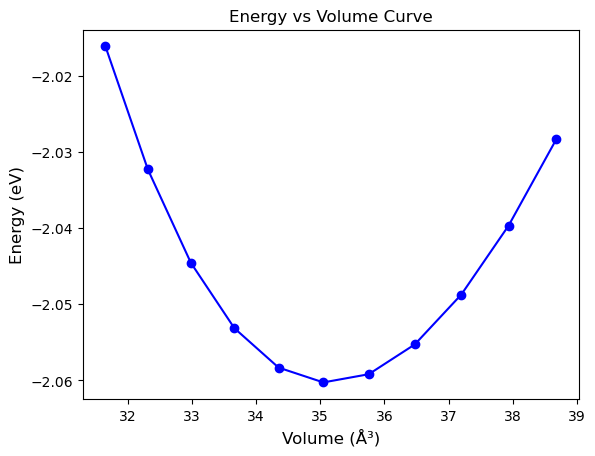

In [23]:
ev_plot = PlotEVCurve(ev_curve_df = ev_curve_df)
ev_plot.pull();

#### <font style="font-family:roboto;color:#455e6c"> Fitting the Birch–Murnaghan Equation of State </font>  


The Birch-Murnaghan EOS is given by,  

$E(V) = E_0 + \frac{9V_0 B_0}{16} \Bigg\{ \Bigg[\frac{V_0}{V}^{\frac{2}{3}} - 1\Bigg]^3 B_0^\prime + \Bigg[ \frac{V_0}{V}^{\frac{2}{3}} - 1\Bigg]^2 \Bigg[ \frac{V_0}{V}^{\frac{2}{3}} \Bigg] \Bigg\}$.


By fitting the EV data to this equation, we can extract the key parameters: the equilibrium energy $E_0$, equilibrium volume $V_0$, bulk modulus $B_0$, and its pressure derivative $B_0'$. This is achieved by invoking the node `FitBirchMurnaghanEOS` and supplying the EV data as input.

In [24]:
fit = FitBirchMurnaghanEOS(ev_curve_df)
E0, V0, B0 = fit.pull()

print(f"E0={E0}, V0={V0}, B0={B0}")

E0=-2.0602970898684103, V0=35.14224771778372, B0=33.93771965849104


### <font style="font-family:roboto;color:#455e6c"> Combine everything in a workflow </font>  

The individual functions described above can be seamlessly integrated into a single workflow using the `pyiron_workflow.Workflow` object. All the steps—from structure generation and optimization to EV curve calculation and EOS fitting—are encapsulated within the `make_murnaghan_workflow` node.

To create the complete workflow, simply provide the element name (which is used to build the structure) and the potential path (which selects the appropriate calculator). This unified workflow streamlines the validation process, making it straightforward to assess the quality of your potentials.


INFO:root:Calculator/self -> optimize_structure/calculator
INFO:root:optimize_settings/self -> optimize_structure/opt
INFO:root:build_structure/structure -> optimize_structure/structure
INFO:root:optimize_structure/relaxed_structure -> calculate_ev_curve/structure
INFO:root:Calculator/self -> calculate_ev_curve/calculator
INFO:root:calculate_ev_curve/df -> fit_eos/ev_curve_df
INFO:root:calculate_ev_curve/df -> plot_ev_curve/ev_curve_df


copy node:  Calculator 43a387ba3f2138e5b4e24fd7230d6be470b535b0848b4d5f2e331ccc2c9bd854
copy node:  optimize_settings 0b02da1ddcd4b3a1a0c5bcec9c52e4c1fb81d11abac25b15f544cf97550f58e1
copy node:  Calculator 43a387ba3f2138e5b4e24fd7230d6be470b535b0848b4d5f2e331ccc2c9bd854
Equilibrium Energy (E0): -2.060296858628369
Equilibrium Volume (V0): 35.14225706564403
Bulk Modulus (B0): 33.93659485522885
copy node:  Calculator 43a387ba3f2138e5b4e24fd7230d6be470b535b0848b4d5f2e331ccc2c9bd854
copy node:  optimize_settings 0b02da1ddcd4b3a1a0c5bcec9c52e4c1fb81d11abac25b15f544cf97550f58e1
copy node:  Calculator 43a387ba3f2138e5b4e24fd7230d6be470b535b0848b4d5f2e331ccc2c9bd854


<Axes: title={'center': 'Energy vs Volume Curve'}, xlabel='Volume (Å³)', ylabel='Energy (eV)'>

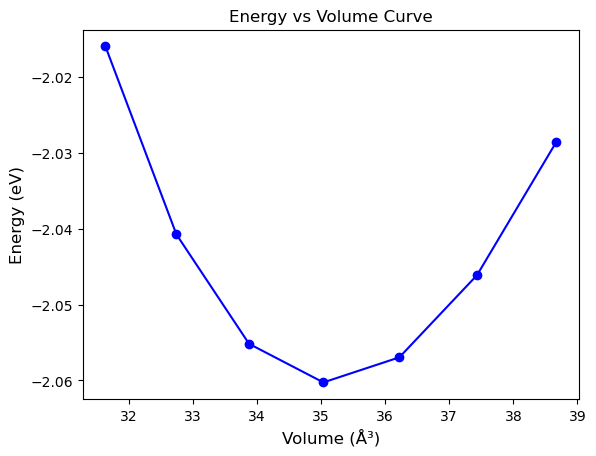

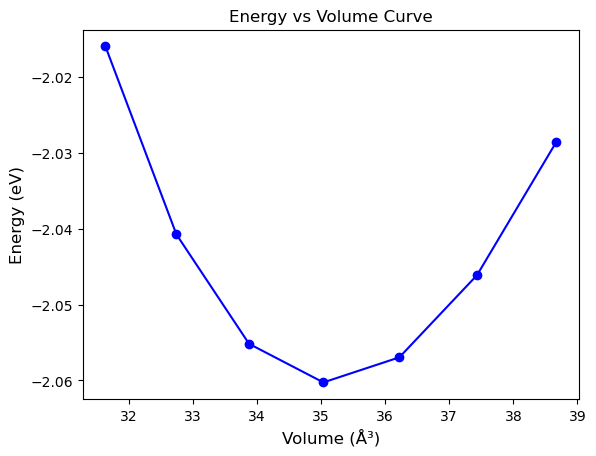

In [25]:
wf = make_murnaghan_workflow("Ca_workflow1",
                             element_str="Ca",
                             potential_path = "potentials/Ca_Mg_linear_potential.yace",
                             delete_existing_savefiles=True)

# run the workflow
wf.run()

# print the output values
print("Equilibrium Energy (E0):", wf.fit_eos.outputs.E0.value)
print("Equilibrium Volume (V0):", wf.fit_eos.outputs.V0.value)
print("Bulk Modulus (B0):", wf.fit_eos.outputs.B0_GPa.value)
wf.plot_ev_curve.pull()

### <font style="font-family:roboto;color:#455e6c"> GUI </font>  

A powerful feature of `pyiron_workflow` is its interactive GUI, which lets you visualize the entire workflow. Through this interface, you can easily inspect the individual nodes and their connections, as well as modify them—either one node at a time or adjust how they interact with each other.


In [26]:
from pyiron_core import PyironFlow

pf = PyironFlow([wf])

implement connect to self
implement connect to self
implement connect to self
connected to node (self)
connected to node (self)
connected to node (self)


In [27]:
pf.gui

### <font style="font-family:roboto;color:#455e6c"> Generate Multiple Workflows to Compare Different Potentials over Multiple Structures </font>  

Now that we have established how to create a workflow for a given structure and potential, we can extend this approach to explore a variety of cases. In this section, we generate multiple workflows by iterating over three different structures—Ca-fcc, Mg-hcp, and a CaMg phase (sourced from the [Materials Project](https://next-gen.materialsproject.org/materials/mp-1039120/))—and testing them against various potentials.

Once these workflows are created, we can run them and then iterate over the results to produce comparison plots. This comprehensive analysis enables us to assess the performance of different potentials across multiple phases.


INFO:root:Calculator/self -> optimize_structure/calculator
INFO:root:optimize_settings/self -> optimize_structure/opt
INFO:root:build_structure/structure -> optimize_structure/structure
INFO:root:optimize_structure/relaxed_structure -> calculate_ev_curve/structure
INFO:root:Calculator/self -> calculate_ev_curve/calculator
INFO:root:calculate_ev_curve/df -> fit_eos/ev_curve_df
INFO:root:calculate_ev_curve/df -> plot_ev_curve/ev_curve_df


copy node:  Calculator 43a387ba3f2138e5b4e24fd7230d6be470b535b0848b4d5f2e331ccc2c9bd854
copy node:  optimize_settings 0b02da1ddcd4b3a1a0c5bcec9c52e4c1fb81d11abac25b15f544cf97550f58e1


INFO:root:Calculator/self -> optimize_structure/calculator


copy node:  Calculator 43a387ba3f2138e5b4e24fd7230d6be470b535b0848b4d5f2e331ccc2c9bd854


INFO:root:optimize_settings/self -> optimize_structure/opt
INFO:root:build_structure/structure -> optimize_structure/structure
INFO:root:optimize_structure/relaxed_structure -> calculate_ev_curve/structure
INFO:root:Calculator/self -> calculate_ev_curve/calculator
INFO:root:calculate_ev_curve/df -> fit_eos/ev_curve_df
INFO:root:calculate_ev_curve/df -> plot_ev_curve/ev_curve_df


...

copy node:  Calculator 43a387ba3f2138e5b4e24fd7230d6be470b535b0848b4d5f2e331ccc2c9bd854
copy node:  optimize_settings 0b02da1ddcd4b3a1a0c5bcec9c52e4c1fb81d11abac25b15f544cf97550f58e1


INFO:root:Calculator/self -> optimize_structure/calculator
INFO:root:optimize_settings/self -> optimize_structure/opt
INFO:root:build_structure/structure -> optimize_structure/structure
INFO:root:optimize_structure/relaxed_structure -> calculate_ev_curve/structure
INFO:root:Calculator/self -> calculate_ev_curve/calculator
INFO:root:calculate_ev_curve/df -> fit_eos/ev_curve_df
INFO:root:calculate_ev_curve/df -> plot_ev_curve/ev_curve_df


copy node:  Calculator 43a387ba3f2138e5b4e24fd7230d6be470b535b0848b4d5f2e331ccc2c9bd854
Using cached GRACE model from /u/janj/.cache/grace/GRACE-1L-OAM
Model license: Academic Software License
copy node:  Calculator ce80ab315e1d8a3fe3fa971c48927b51f8990f2be4a8c987a8e92d57d484cfc3
copy node:  optimize_settings 0b02da1ddcd4b3a1a0c5bcec9c52e4c1fb81d11abac25b15f544cf97550f58e1
Using cached GRACE model from /u/janj/.cache/grace/GRACE-1L-OAM
Model license: Academic Software License
copy node:  Calculator ce80ab315e1d8a3fe3fa971c48927b51f8990f2be4a8c987a8e92d57d484cfc3
Using cached GRACE model from /u/janj/.cache/grace/GRACE-1L-OAM
Model license: Academic Software License
Using cached GRACE model from /u/janj/.cache/grace/GRACE-1L-OAM
Model license: Academic Software License
Using cached GRACE model from /u/janj/.cache/grace/GRACE-1L-OAM
Model license: Academic Software License
Using cached GRACE model from /u/janj/.cache/grace/GRACE-1L-OAM
Model license: Academic Software License
Using cache

INFO:root:Calculator/self -> optimize_structure/calculator
INFO:root:optimize_settings/self -> optimize_structure/opt
INFO:root:build_structure/structure -> optimize_structure/structure
INFO:root:optimize_structure/relaxed_structure -> calculate_ev_curve/structure
INFO:root:Calculator/self -> calculate_ev_curve/calculator
INFO:root:calculate_ev_curve/df -> fit_eos/ev_curve_df
INFO:root:calculate_ev_curve/df -> plot_ev_curve/ev_curve_df


Using cached GRACE model from /u/janj/.cache/grace/GRACE-2L-OAM
Model license: Academic Software License
copy node:  Calculator 29bc2c04ef764f5ef4e80c05c9e3488693e3bad4c4760cea7a99786389e7e2c4
copy node:  optimize_settings 0b02da1ddcd4b3a1a0c5bcec9c52e4c1fb81d11abac25b15f544cf97550f58e1
Using cached GRACE model from /u/janj/.cache/grace/GRACE-2L-OAM
Model license: Academic Software License
copy node:  Calculator 29bc2c04ef764f5ef4e80c05c9e3488693e3bad4c4760cea7a99786389e7e2c4
Using cached GRACE model from /u/janj/.cache/grace/GRACE-2L-OAM
Model license: Academic Software License
Using cached GRACE model from /u/janj/.cache/grace/GRACE-2L-OAM
Model license: Academic Software License
Using cached GRACE model from /u/janj/.cache/grace/GRACE-2L-OAM
Model license: Academic Software License
Using cached GRACE model from /u/janj/.cache/grace/GRACE-2L-OAM
Model license: Academic Software License
Using cached GRACE model from /u/janj/.cache/grace/GRACE-2L-OAM
Model license: Academic Software Li

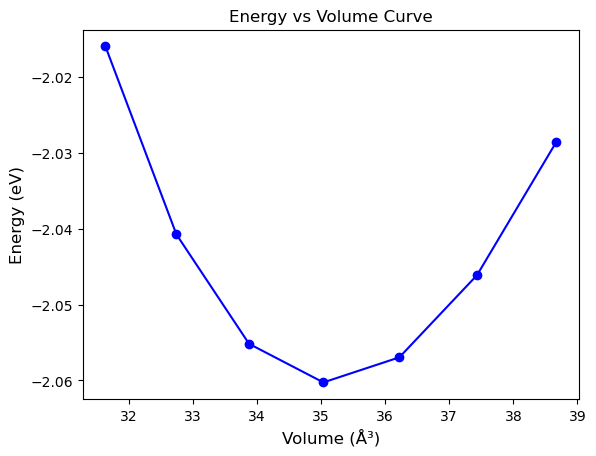

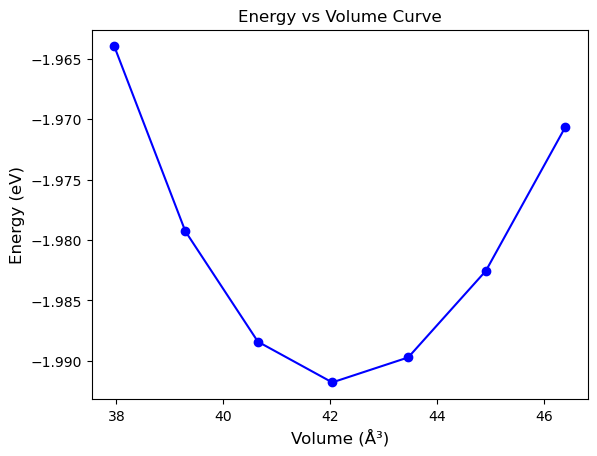

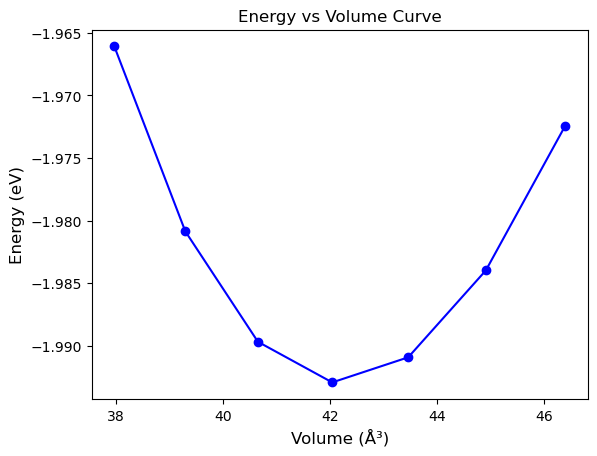

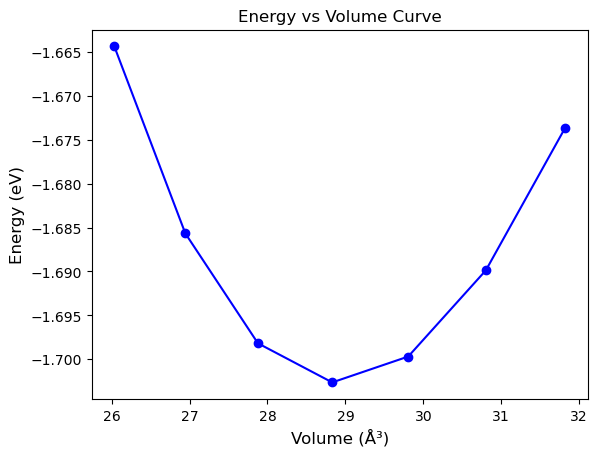

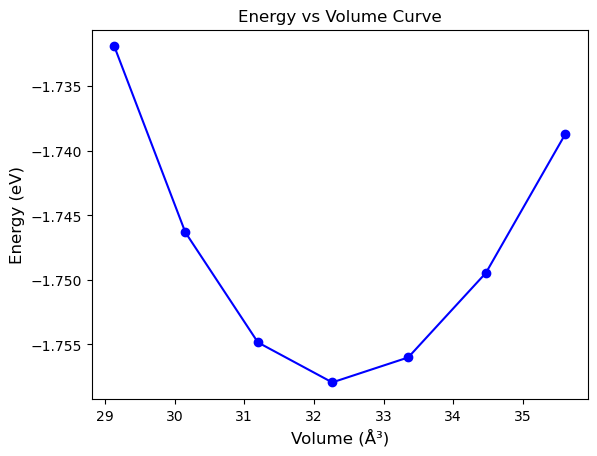

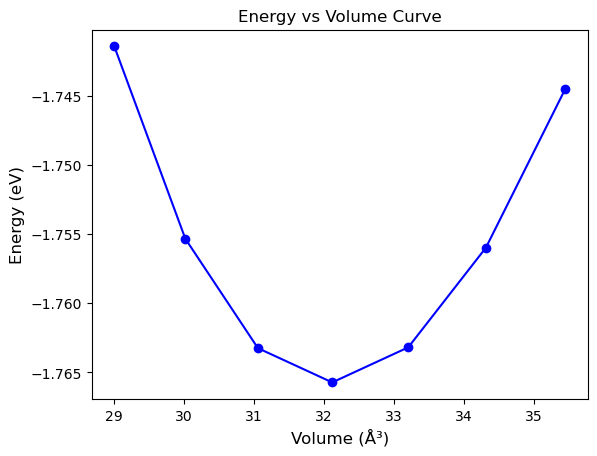

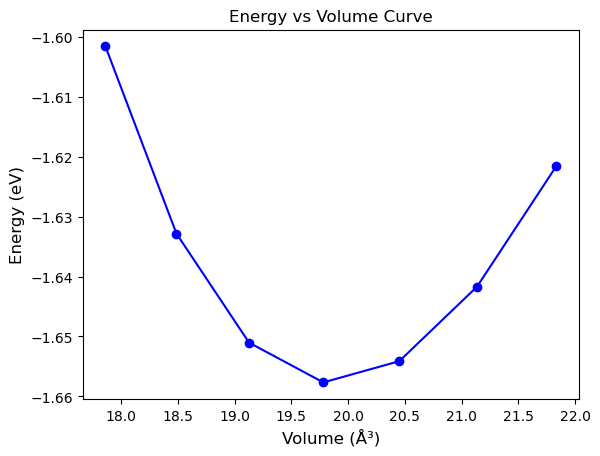

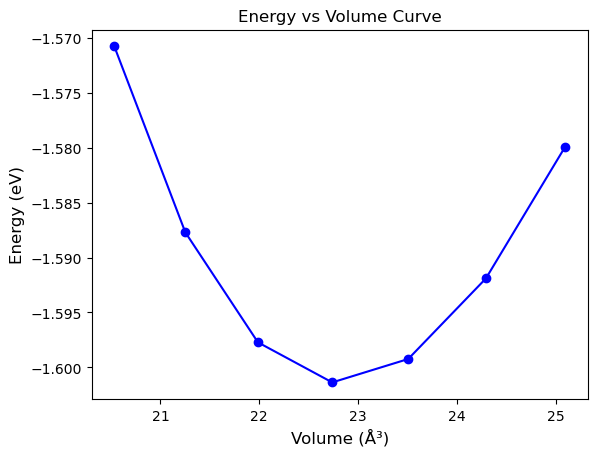

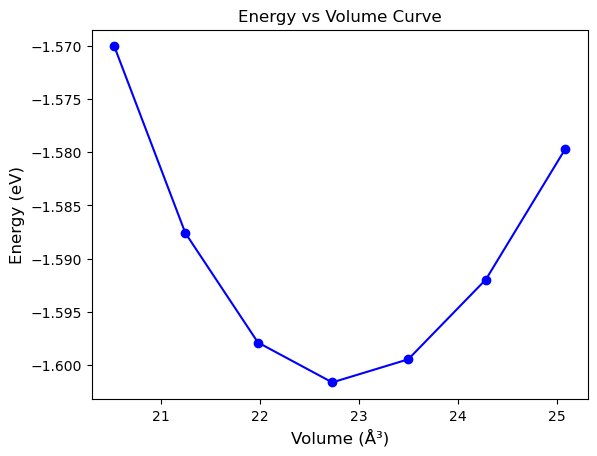

In [28]:
import os
import matplotlib.pyplot as plt


# Structure labels as element-strings: (the actual atomic structures are generated within the workflow)
struc_labels = ["Ca", "CaMg", "Mg",]

# Define potential paths and assign labels (these labels will be part of the workflow name)
potentials = {
    'LinearACE': "potentials/Ca_Mg_linear_potential.yace",
    # "ACE_nfuncs_10": "potentials/Bad_linear_potential.yace",
    # "ACE_nfuncs_50": "potentials/Better_potential.yace",
    # "GRACE_1L_r6": "MP_GRACE_1L_r6_07Nov2024",
    "GRACE_1L_OAM": "GRACE-1L-OAM",
    "GRACE_2L_OAM" : "GRACE-2L-OAM"
}

# Create an empty dictionary to store the workflows:
workflows = {}

# Loop over all structure and potential combinations:
for struc_label in struc_labels:
    for pot_label, pot_path in potentials.items():
        
        # Create a unique workflow name
        wf_name = f"{struc_label}_{pot_label}"
        
        wf = make_murnaghan_workflow(
            workflow_name=wf_name,
            element_str=struc_label,
            potential_path=pot_path,
            delete_existing_savefiles=True
        )
        # Set the structure input (other inputs like fmax, max_steps, etc. can be set here as needed)
        # wf.inputs.structure = structure
        
        # Run the workflow.
        wf.run()
        
        # Save the workflow object for later analysis/plotting.
        workflows[wf_name] = wf

In [29]:
# DFT references taken from https://doi.org/10.1103/PhysRevB.107.104103

ref_e0 = {"Ca": -1.930,
          "Mg" : -1.506,
          "CaMg" : -1.802}

ref_V = {"Ca": 42.193,
          "Mg" : 22.953,
          "CaMg" : 30.939}

Ca_LinearACE
Ca_GRACE_1L_OAM
Ca_GRACE_2L_OAM
CaMg_LinearACE
CaMg_GRACE_1L_OAM
CaMg_GRACE_2L_OAM
Mg_LinearACE
Mg_GRACE_1L_OAM
Mg_GRACE_2L_OAM


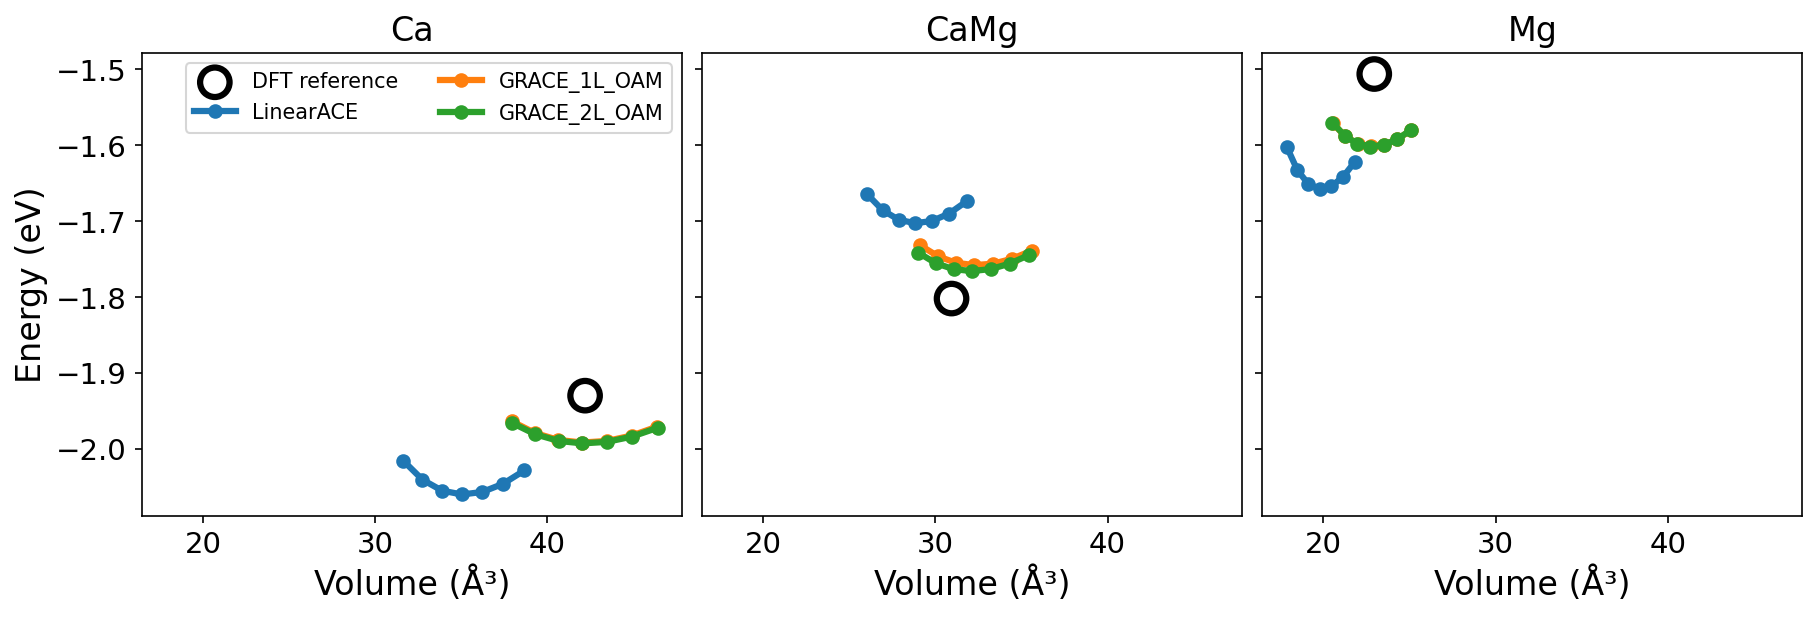

In [30]:
fontsize = 16

fig, ax_list = plt.subplots(ncols=3, dpi=150, sharex=True, sharey=True, figsize=(12,4), constrained_layout=True)

ii = 0
for ii, struc_label in enumerate(struc_labels):
    ax = ax_list[ii]
    ii += 1

    ref_e = ref_e0[struc_label]
    ref_v = ref_V[struc_label]
    # ax.axhline(ref_e, ls="--", label="DFT reference")
    ax.scatter(ref_v,ref_e, 
               marker="o",
               s=200,
               facecolor="None",
               edgecolor="k",
               lw=3,
               zorder=5,
               label="DFT reference"
              )

    
    for jj,pot_label in enumerate(potentials.keys()):
        wf_name = f"{struc_label}_{pot_label}"
        print(wf_name)

        wf = workflows[wf_name]
        df = wf.calculate_ev_curve.outputs.df.value
        
        ax.plot(df['volume'], df['energy'],
                'o-', 
                lw=3,
                label=f"{pot_label}")
        ax.set_xlabel("Volume (Å³)",fontsize=fontsize)
        ax.tick_params(labelsize=fontsize-2)
        ax.set_title(struc_label,fontsize=fontsize)
        


ax_list[0].set_ylabel("Energy (eV)",fontsize=fontsize)
ax_list[0].legend(prop={"size":fontsize-6}, ncol=2)

# plt.tight_layout()
plt.show()

Thus we can neatly compare the different potentials with DFT references. For the above plots, the DFT references are taken from [Poul et. al.](https://doi.org/10.1103/PhysRevB.107.104103) 

In [31]:
# DFT references taken from https://doi.org/10.1103/PhysRevB.107.104103

ref_B0 = {"Ca": 17.500,
          "CaMg" : 25.769,
          "Mg" : 36.434,
          }

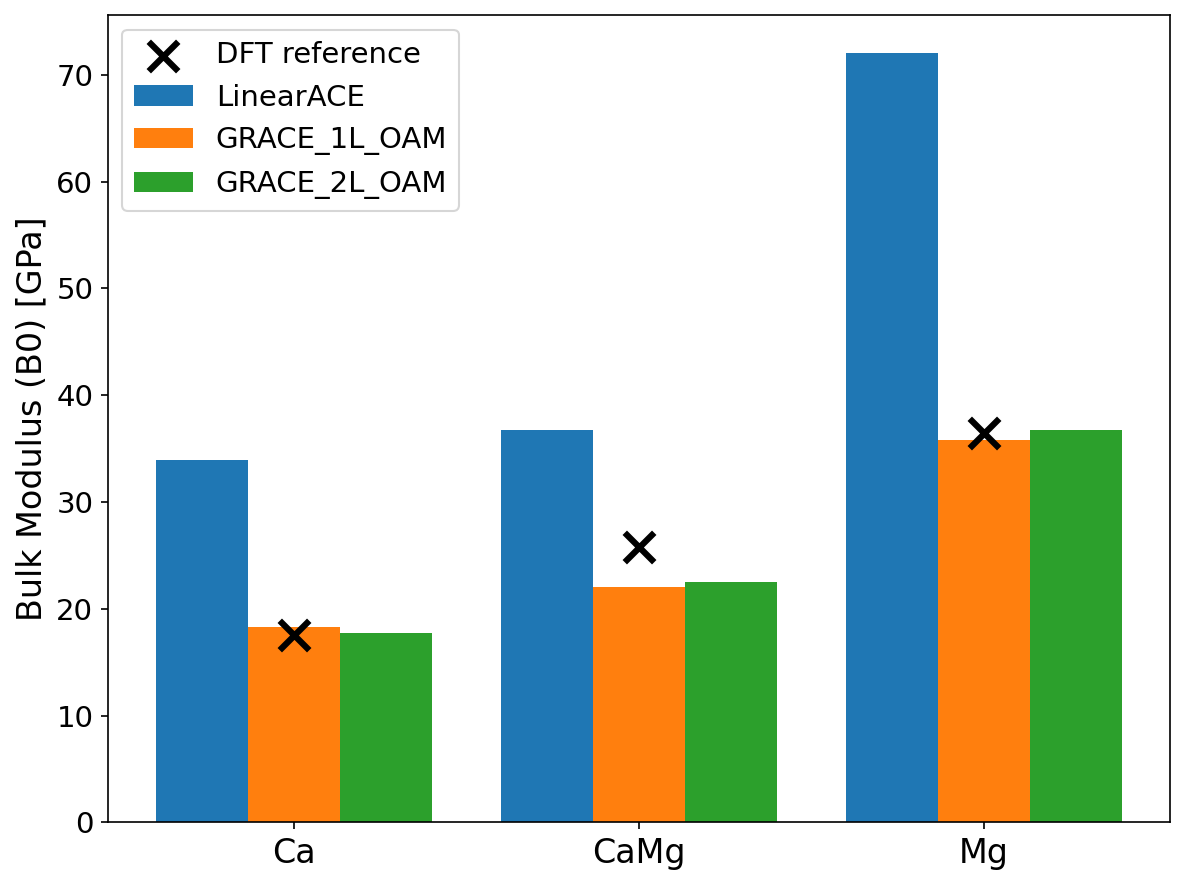

In [32]:
import numpy as np
import matplotlib.pyplot as plt

fontsize = 16

# Define the order of structures and potentials.
structures = list(struc_labels)  
pot_labels = list(potentials.keys())   

B0_values = []  # rows: structures, columns: potentials

for struc_label in structures:
    B0_row = []
    for pot_label in pot_labels:
        wf_name = f"{struc_label}_{pot_label}"
        wf = workflows[wf_name]
        # Assuming your FitBirchMurnaghanEOS node returns a dictionary mapped to 'eos'
        B0 = wf.fit_eos.outputs.B0_GPa.value
        B0_row.append(B0)
    B0_values.append(B0_row)

B0_values = np.array(B0_values)  # Shape: (n_structures, n_potentials)

# Plotting a grouped bar chart.
fig, ax = plt.subplots(dpi=150, figsize=(8, 6))

n_groups = len(structures)
n_bars = len(pot_labels)
index = np.arange(n_groups)  # positions for groups on the x-

ax.scatter(index, ref_B0.values(),
           marker="x",
           s=200,
           color="k",
           label="DFT reference",
           lw=3,
           zorder=5,
          )

total_group_width = 0.8  
bar_width = total_group_width / n_bars  

for i, pot_label in enumerate(pot_labels):
    # Compute offset so that bars are centered on each group position.
    offset = (i - (n_bars - 1) / 2) * bar_width
    ax.bar(index + offset, B0_values[:, i], bar_width, label=pot_label)

ax.set_ylabel("Bulk Modulus (B0) [GPa]", fontsize=fontsize)
ax.set_xticks(index)
ax.set_xticklabels(structures, fontsize=fontsize)
ax.tick_params(axis="y", labelsize=fontsize-2)
ax.legend(fontsize=fontsize-2)

plt.tight_layout()
plt.show()


DFT references are taken from [Poul et. al.](https://doi.org/10.1103/PhysRevB.107.104103) 

<img src="img/logo_roll.png" width="1200">